In [6]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u
from tqdm import tqdm
from pathlib import Path

In [7]:
full_df = pd.read_csv('final_full_data_centered.csv')

In [8]:
full_df['Name'].nunique()

9647

In [9]:
sd = 4
# Per-epoch detection (handles NaN / RMS=0 safely)
full_df["Detection"] = (
    full_df["Peak Luminosity"].notna() &
    full_df["RMS"].notna() &
    (full_df["RMS"] != 0) &
    (full_df["Peak Luminosity"] >= sd * full_df["RMS"])
)


In [10]:
full_df.loc[full_df["Detection"], "Name"].nunique()

275

In [11]:
post_mask = full_df['Rest_DeltaT'] > 0
pre_mask = full_df['Rest_DeltaT'] < 0 

# Detection flags per object
has_post_detection = full_df.loc[post_mask].groupby("Name")["Detection"].any()
has_pre_detection  = full_df.loc[pre_mask].groupby("Name")["Detection"].any()

# Make sure every object appears in both Series
all_names = full_df["Name"].unique()
has_post_detection = has_post_detection.reindex(all_names, fill_value=False)
has_pre_detection  = has_pre_detection.reindex(all_names, fill_value=False)

valid_names = has_post_detection & ~has_pre_detection
valid_names = valid_names[valid_names].index

det_df = full_df[full_df['Name'].isin(valid_names)].copy()

In [12]:
detected_transients = det_df['Name'].unique()
pd.Series(detected_transients).to_csv('detected97.csv', index = False)

In [13]:
# -----------------------------
# 1) Pre–first-light baseline (dt <= 0), closest to 0
# -----------------------------
pre = det_df.loc[
    det_df["Rest_DeltaT"].le(0) &
    det_df["Peak Luminosity"].notna() &
    det_df["RMS"].notna() &
    (det_df["RMS"] != 0)
].copy()

pre_idx = pre.groupby("Name")["Rest_DeltaT"].idxmax()

pre_rows = det_df.loc[pre_idx, ["Name", "Peak Luminosity", "RMS"]].rename(
    columns={
        "Peak Luminosity": "pre_flux",
        "RMS": "pre_rms"
    }
)

# -----------------------------
# 2) Post-explosion peak (dt >= 0), keep its RMS
# -----------------------------
post = det_df.loc[
    det_df["Rest_DeltaT"].ge(0) &
    det_df["Peak Luminosity"].notna() &
    det_df["RMS"].notna() &
    (det_df["RMS"] != 0)
].copy()

post_idx = post.groupby("Name")["Peak Luminosity"].idxmax()

post_rows = det_df.loc[post_idx, ["Name", "Peak Luminosity", "RMS"]].rename(
    columns={"Peak Luminosity": "post_flux", "RMS": "post_rms"}
)

# -----------------------------
# 3) Apply ≥4σ brightening criterion
# -----------------------------
event_df = pre_rows.merge(post_rows, on="Name", how="inner")

# --- Version A: use ONLY post RMS 
event_df["Candidate_prepost4sigma_postonly"] = (
    event_df["post_flux"] >=
    event_df["pre_flux"] + 4 * event_df["post_rms"]
)

# --- Version B: use QUADRATURE 
event_df["combined_rms"] = np.sqrt(event_df["pre_rms"]**2 + event_df["post_rms"]**2)

event_df["Candidate_prepost4sigma_quadrature"] = (
    event_df["post_flux"] >=
    event_df["pre_flux"] + 4 * event_df["combined_rms"]
)

# event_df["Candidate_prepost4sigma"] = event_df["Candidate_prepost4sigma_postonly"]
event_df["Candidate_prepost4sigma"] = event_df["Candidate_prepost4sigma_quadrature"]

In [14]:
# -----------------------------
# 4) Get list of candidate Names
# -----------------------------
candidate_names = event_df.loc[
    event_df["Candidate_prepost4sigma"],
    "Name"
].tolist()
# -----------------------------
# 5) DataFrame with ALL epochs for those objects
# -----------------------------
candidate_df = det_df[det_df["Name"].isin(candidate_names)].copy()
# All detected objects that are NOT in candidate_df
noncandidate_df = det_df[~det_df["Name"].isin(candidate_df["Name"])].copy()


In [15]:
import numpy as np

def any_pair_passes(g, sd=4, use_quadrature=True):
    g = g.dropna(subset=["Peak Luminosity", "RMS", "Rest_DeltaT"]).copy()
    g = g[g["RMS"] != 0]

    if len(g) < 2:
        return False

    g = g.sort_values("Rest_DeltaT")

    peaks = g["Peak Luminosity"].to_numpy()
    rms   = g["RMS"].to_numpy()

    n = len(g)
    for i in range(n - 1):
        for j in range(i + 1, n):
            if use_quadrature:
                combined_rms = np.sqrt(rms[i]**2 + rms[j]**2)
            else:
                combined_rms = rms[j]  # "local" later-epoch RMS

            if abs(peaks[j] - peaks[i]) >= sd * combined_rms:
                return True

    return False


In [16]:
# --- Apply to every object in noncandidate_df ---
pair_flag = (
    noncandidate_df.groupby("Name")
    .apply(any_pair_passes, sd=4, use_quadrature = True)
    .rename("Candidate_pairwise4sigma")
    .reset_index()
)

pair_names = pair_flag.loc[pair_flag["Candidate_pairwise4sigma"], "Name"].tolist()

candidate_pairwise_df = noncandidate_df[noncandidate_df["Name"].isin(pair_names)].copy()

In [17]:
print('\n'.join(pair_names))

ZTF18abtgkdo
ZTF18acbwopo
ZTF19aakkths
ZTF19aakswrb
ZTF19aaqwqhu
ZTF22aaagrce


In [18]:
candidate_names


print("\n".join(candidate_names))

ZTF18acpdvos
ZTF19abpidqn
ZTF19abucwzt
ZTF19acxxwvi
ZTF19adaxzax
ZTF20aaieyup
ZTF20acaazkt
ZTF20acnvniw
ZTF20acytgxf
ZTF21aagtpro
ZTF21ablwehd
ZTF21abzciqh
ZTF22abajudi
ZTF23aaqdjhi
ZTF24aahgqwk


In [19]:
print("\n".join(sorted(set(pair_names) | set(candidate_names))))


ZTF18abtgkdo
ZTF18acbwopo
ZTF18acpdvos
ZTF19aakkths
ZTF19aakswrb
ZTF19aaqwqhu
ZTF19abpidqn
ZTF19abucwzt
ZTF19acxxwvi
ZTF19adaxzax
ZTF20aaieyup
ZTF20acaazkt
ZTF20acnvniw
ZTF20acytgxf
ZTF21aagtpro
ZTF21ablwehd
ZTF21abzciqh
ZTF22aaagrce
ZTF22abajudi
ZTF23aaqdjhi
ZTF24aahgqwk


In [21]:
import numpy as np

def debug_any_pair(g, sd=4, name=None, max_pairs=200, use_quadrature=True):
    g = g.dropna(subset=["Peak Luminosity", "RMS", "Rest_DeltaT"]).copy()
    g = g[g["RMS"] != 0].sort_values("Rest_DeltaT")

    # Add S/N column
    g["SNR"] = g["Peak Luminosity"] / g["RMS"]

    if name is None and "Name" in g.columns and len(g) > 0:
        name = g["Name"].iloc[0]

    mode = "quadrature (sqrt(rms_i^2 + rms_j^2))" if use_quadrature else "post-only (rms_j)"
    print(f"\n=== DEBUG: {name} | mode: {mode} | sd={sd} ===")

    if len(g) < 2:
        print("Not enough valid epochs after filtering (need >= 2).")
        print(g[["Rest_DeltaT", "Peak Luminosity", "RMS", "SNR"]])
        return False

    print("\nRows used (sorted by Rest_DeltaT):")
    print(g[["Rest_DeltaT", "Peak Luminosity", "RMS", "SNR"]].to_string(index=True))

    peaks = g["Peak Luminosity"].to_numpy()
    rms   = g["RMS"].to_numpy()
    dts   = g["Rest_DeltaT"].to_numpy()
    snr   = g["SNR"].to_numpy()

    n = len(g)
    passed = False
    count = 0

    print("\nPair checks:")
    for i in range(n - 1):
        for j in range(i + 1, n):
            if use_quadrature:
                sigma = np.sqrt(rms[i]**2 + rms[j]**2)
            else:
                sigma = rms[j]

            delta = peaks[j] - peaks[i]
            thresh = sd * sigma
            ok = abs(delta) >= thresh

            print(
                f" i={i} (dt={dts[i]:.2f}, S/N={snr[i]:.2f})  "
                f"j={j} (dt={dts[j]:.2f}, S/N={snr[j]:.2f}) | "
                f"Δ={delta:.3e}  |Δ|={abs(delta):.3e}  "
                f"σ={sigma:.3e}  sd*σ={thresh:.3e}  -> {ok}"
            )

            if ok:
                passed = True

            count += 1
            if count >= max_pairs:
                print(f"...stopped after {max_pairs} pairs")
                return passed

    print(f"\nResult: {passed}")
    return passed

In [22]:
['ZTF18acbwopo',
 'ZTF19aakkths',
 'ZTF19aakswrb',
 'ZTF19abxqppy',
 'ZTF19adcfsad',
 'ZTF20abegirf',
 'ZTF23aabngtm',
 'ZTF23abbccir'
 
 
 
 
 ]

['ZTF18acbwopo',
 'ZTF19aakkths',
 'ZTF19aakswrb',
 'ZTF19abxqppy',
 'ZTF19adcfsad',
 'ZTF20abegirf',
 'ZTF23aabngtm',
 'ZTF23abbccir']

In [23]:
name = "ZTF22aaemvhi"  # <- replace
g = noncandidate_df[noncandidate_df["Name"] == name]
debug_any_pair(g, sd=4, name=name, use_quadrature= True)


=== DEBUG: ZTF22aaemvhi | mode: quadrature (sqrt(rms_i^2 + rms_j^2)) | sd=4 ===

Rows used (sorted by Rest_DeltaT):
       Rest_DeltaT  Peak Luminosity           RMS       SNR
18624  -980.070088     5.942900e+27  2.524733e+27  2.353873
18625   -56.316422     8.634265e+27  2.623887e+27  3.290639
18626   831.269110     1.548647e+28  3.114225e+27  4.972818

Pair checks:
 i=0 (dt=-980.07, S/N=2.35)  j=1 (dt=-56.32, S/N=3.29) | Δ=2.691e+27  |Δ|=2.691e+27  σ=3.641e+27  sd*σ=1.457e+28  -> False
 i=0 (dt=-980.07, S/N=2.35)  j=2 (dt=831.27, S/N=4.97) | Δ=9.544e+27  |Δ|=9.544e+27  σ=4.009e+27  sd*σ=1.604e+28  -> False
 i=1 (dt=-56.32, S/N=3.29)  j=2 (dt=831.27, S/N=4.97) | Δ=6.852e+27  |Δ|=6.852e+27  σ=4.072e+27  sd*σ=1.629e+28  -> False

Result: False


False

In [8]:
full_df[full_df['Name'] == 'ZTF17aaazdba']

,Name,Epoch,RA,Dec,type,redshift,Distance_Mpc,Rest_DeltaT,File Path,RMS,Peak Luminosity,Detection
3,ZTF17aaazdba,1,08:13:16.95,+22:38:53.9,TDE,0.022,94.285714,49.882583,final_luminosity_arrays\ZTF17aaazdba_epoch_1_l...,2.217389e+27,5.020735e+27,False
4,ZTF17aaazdba,2,08:13:16.95,+22:38:53.9,TDE,0.022,94.285714,1002.915851,final_luminosity_arrays\ZTF17aaazdba_epoch_2_l...,1.577927e+27,1.173864e+28,True
5,ZTF17aaazdba,3,08:13:16.95,+22:38:53.9,TDE,0.022,94.285714,1857.123288,final_luminosity_arrays\ZTF17aaazdba_epoch_3_l...,1.360889e+27,7.425113e+27,True


In [113]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_transient_epochs(df, name,
                          name_col="Name",
                          epoch_col="Epoch",
                          path_col="File Path",
                          rms_col="RMS",
                          peak_col="Peak Luminosity",
                          dt_col="Rest_DeltaT",
                          cmap="inferno",
                          border_snr_threshold=4,
                          border_color="lime",
                          savepath=None):
    """
    Plot all available epochs for a transient in a single row.
    Uses stored RMS and Peak Luminosity columns (does NOT recompute).

    Matches your formatting:
      - Title: Name, Epoch, Δt
      - X label: RMS, Max Flux, S/N
      - Lime border if S/N > threshold
    """

    # Filter object
    g = df[df[name_col] == name].copy()

    if len(g) == 0:
        raise ValueError(f"No rows found for object '{name}'")

    # Sort by epoch
    g = g.sort_values(epoch_col)

    n = len(g)

    fig, axs = plt.subplots(1, n, figsize=(4*n, 4), constrained_layout=True)

    # Ensure axs is iterable even if n=1
    if n == 1:
        axs = [axs]

    fig.suptitle(name, fontsize=14)

    for ax, (_, row) in zip(axs, g.iterrows()):

        path = row[path_col]

        if not os.path.exists(path):
            ax.set_title(f"Missing file")
            ax.axis("off")
            continue

        arr = np.load(path)

        rms = row[rms_col]
        peak = row[peak_col]
        snr = peak / rms if rms != 0 else np.nan

        epoch = row[epoch_col]
        delta_t = row.get(dt_col, np.nan)

        # Plot image
        ax.imshow(arr, cmap=cmap, interpolation="nearest", origin="lower")

        ax.set_title(
            f"{name}: Epoch {epoch}, Δt: {delta_t:.0f}d",
            fontsize=9
        )

        ax.set_xlabel(
            "RMS: {:.3e}, Max Lum: {:.3e}\nS/N: {:.3f}".format(rms, peak, snr),
            fontsize=9
        )

        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

        # Border color based on S/N
        if np.isfinite(snr) and snr > border_snr_threshold:
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(4)
        else:
            for spine in ax.spines.values():
                spine.set_edgecolor("black")
                spine.set_linewidth(1)


    plt.show()

    return fig, axs


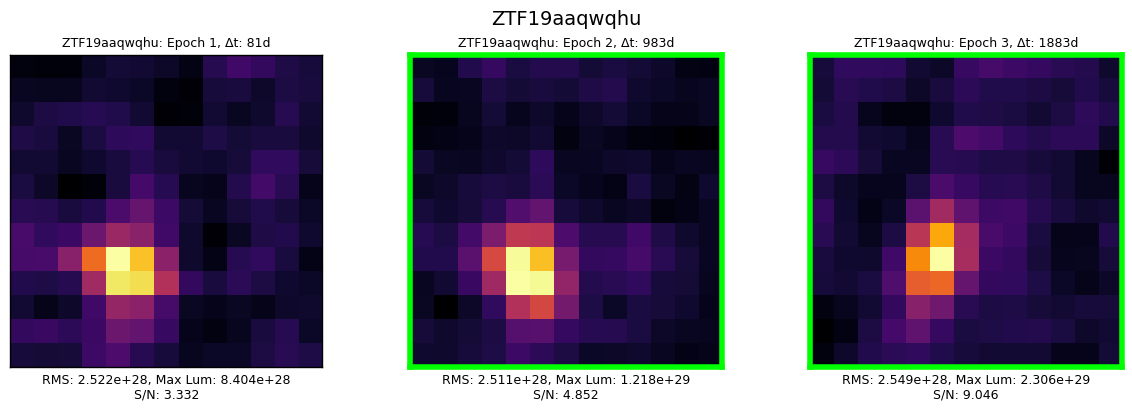

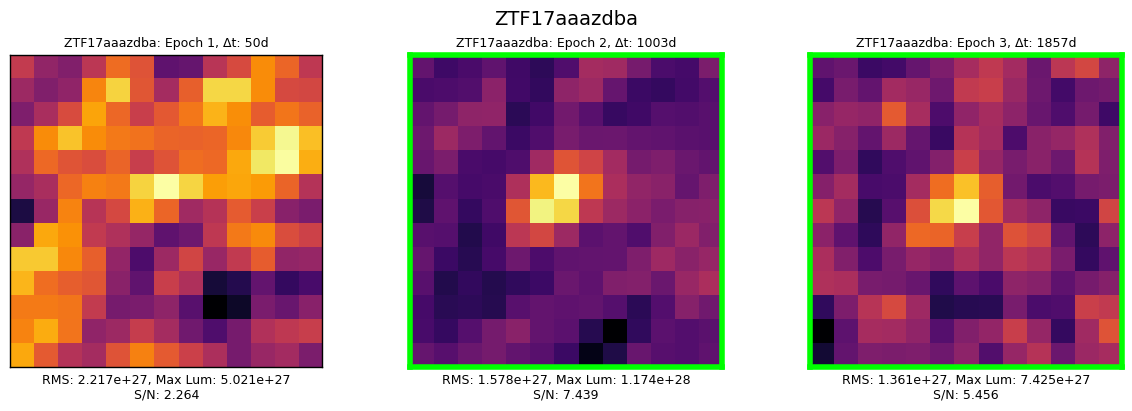

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'ZTF17aaazdba: Epoch 1, Δt: 50d'}, xlabel='RMS: 2.217e+27, Max Lum: 5.021e+27\nS/N: 2.264'>,
        <Axes: title={'center': 'ZTF17aaazdba: Epoch 2, Δt: 1003d'}, xlabel='RMS: 1.578e+27, Max Lum: 1.174e+28\nS/N: 7.439'>,
        <Axes: title={'center': 'ZTF17aaazdba: Epoch 3, Δt: 1857d'}, xlabel='RMS: 1.361e+27, Max Lum: 7.425e+27\nS/N: 5.456'>],
       dtype=object))

In [115]:
plot_transient_epochs(full_df, 'ZTF19aaqwqhu')
plot_transient_epochs(full_df, 'ZTF17aaazdba')

In [38]:
import numpy as np

name = "ZTF20aclwclm"  # replace with your object name

rows = det_df[det_df["Name"] == name]

for _, row in rows.iterrows():
    print(f"\nEpoch {row['Epoch']}")
    print(np.load(row["File Path"]))



Epoch 1
[[5.13602601e+26 6.15287402e+26 5.48383655e+26 3.41593424e+26
  2.32582276e+26 5.06413898e+26 5.17937106e+26 3.99089118e+26
  5.57845233e+26 4.65766396e+26 4.11191833e+26 4.01149526e+26
  8.65481063e+26]
 [4.31573961e+26 6.36571738e+26 3.70148843e+26 3.66394252e+26
  4.79737646e+26 4.77765174e+26 3.89691991e+26 3.03457897e+26
  4.59103528e+26 5.22430814e+26 3.59672378e+26 2.86128469e+26
  8.94281878e+26]
 [6.39588879e+26 5.16149691e+26 3.68759693e+26 7.24172981e+26
  9.03616590e+26 7.63837859e+26 6.69698429e+26 2.96429730e+26
  3.74804531e+26 6.98136983e+26 7.70653262e+26 8.42077645e+26
  9.18925059e+26]
 [5.10571607e+26 4.21862615e+26 5.76255037e+26 1.18308523e+27
  1.58476351e+27 1.18372841e+27 6.24019938e+26 3.98164092e+26
  4.14114000e+26 7.68760168e+26 1.20110429e+27 1.12599765e+27
  1.02578120e+27]
 [5.70513750e+26 3.39538499e+26 3.41156414e+26 1.10287893e+27
  1.78187488e+27 1.17963619e+27 4.33948995e+26 3.67709579e+26
  2.55952561e+26 6.81183966e+26 9.39668411e+26 9.01

In [ ]:
full_df

,Name,Epoch,RA,Dec,type,redshift,Distance_Mpc,Rest_DeltaT,File Path,RMS,Peak Luminosity,Centered Peak Luminosity
0,ZTF17aaapufz,1,12:35:52.28,+27:55:55.4,LBV,0.00261,11.185714,595.465834,final_luminosity_arrays\ZTF17aaapufz_epoch_1_l...,1.711853e+25,5.824115e+25,6.885868e+24
1,ZTF17aaapufz,2,12:35:52.28,+27:55:55.4,LBV,0.00261,11.185714,1609.818374,final_luminosity_arrays\ZTF17aaapufz_epoch_2_l...,2.247826e+25,5.911585e+25,5.911585e+25
2,ZTF17aaapufz,3,12:35:52.28,+27:55:55.4,LBV,0.00261,11.185714,2496.504124,final_luminosity_arrays\ZTF17aaapufz_epoch_3_l...,1.893125e+25,4.810369e+25,3.179669e+25
3,ZTF17aaazdba,1,08:13:16.95,+22:38:53.9,TDE,0.02200,94.285714,49.882583,final_luminosity_arrays\ZTF17aaazdba_epoch_1_l...,2.217389e+27,5.020735e+27,5.020735e+27
4,ZTF17aaazdba,2,08:13:16.95,+22:38:53.9,TDE,0.02200,94.285714,1002.915851,final_luminosity_arrays\ZTF17aaazdba_epoch_2_l...,1.577927e+27,1.173864e+28,1.173864e+28
...,...,...,...,...,...,...,...,...,...,...,...,...
28852,ZTF24abjdahk,2,01:19:38.87,+07:07:41.4,SN Ia,0.06700,287.142857,-1418.468317,final_luminosity_arrays\ZTF24abjdahk_epoch_2_l...,1.445425e+28,3.900589e+28,1.736389e+28
28853,ZTF24abjdahk,3,01:19:38.87,+07:07:41.4,SN Ia,0.06700,287.142857,-471.889123,final_luminosity_arrays\ZTF24abjdahk_epoch_3_l...,1.209562e+28,3.083211e+28,8.610681e+27
28854,ZTF24abjjeet,1,03:17:04.09,+47:07:15.2,SN Ia,0.03000,128.571429,-1871.189995,final_luminosity_arrays\ZTF24abjjeet_epoch_1_l...,2.767207e+27,6.100528e+27,3.658472e+27
28855,ZTF24abjjeet,2,03:17:04.09,+47:07:15.2,SN Ia,0.03000,128.571429,-1007.112325,final_luminosity_arrays\ZTF24abjjeet_epoch_2_l...,2.401184e+27,6.206714e+27,2.297708e+27
